<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Logistic Regression Practice

---

# Titanic
On April 15, 1912, the RMS Titanic sank after colliding with an iceberg, killing over 1,500 of its 2,224 passengers and crew. Survival wasn't random — factors like class, sex, and age all played a role in who made it into a lifeboat.

You will be predicting `Survived`: whether a passenger survived (1) or did not (0), using their ticket and demographic information.

# Imports

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, recall_score, precision_score, f1_score

### 1. Load the data

Read in the `titanic.csv` data.

In [3]:
# TODO:
df = pd.read_csv('./data/titanic.csv')

### 2. Drop columns that won’t help the model

> `PassengerId` is just a row ID, `Name` and `Ticket` are high-cardinality free text, and `Cabin` is missing for the vast majority of passengers.

In [4]:
# TODO:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

### 3. Handle missing values

> Check for missing values. `Age` and `Embarked` both have null values, fill them in (median for `Age` and the most common value for `Embarked`).

In [5]:
# TODO:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Modeling

### 4. Set up your target and features, and split into training and testing sets

Set `Survived` as your target, `y`. Everything else remaining is your feature matrix, `X`.

In [6]:
# TODO:

y = df['Survived']
X = df.drop(columns=['Survived'])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 5. Establish a baseline

What accuracy would you get by always predicting the majority class? This is the number your model needs to beat.

In [7]:
# TODO:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

baseline_acc = dummy.score(X_test, y_test)
print(f"Baseline (Majority Class) Accuracy: {baseline_acc:.4f}")

Baseline (Majority Class) Accuracy: 0.6145


### 6. Build a `Pipeline` with a `ColumnTransformer`

> Use a `ColumnTransformer` to scale your numeric features and encode your categorical features. Then chain it into a `Pipeline`.

In [8]:
# TODO:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
cat_cols = ['Sex', 'Embarked', 'Pclass']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

model_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

### 7. Fit your pipeline and evaluate train vs. test accuracy

Is there a meaningful gap between train and test performance? Is this model better than the null model?

In [9]:
# TODO:
model_pipeline.fit(X_train, y_train)

train_acc = model_pipeline.score(X_train, y_train)
test_acc = model_pipeline.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

Train Accuracy: 0.8104
Test Accuracy:  0.8045


### 8. Confusion matrix

> Generate a confusion matrix for your model's predictions on the test set. Which type of mistake is your model making more (predicting survival for someone who didn't, or the reverse?)

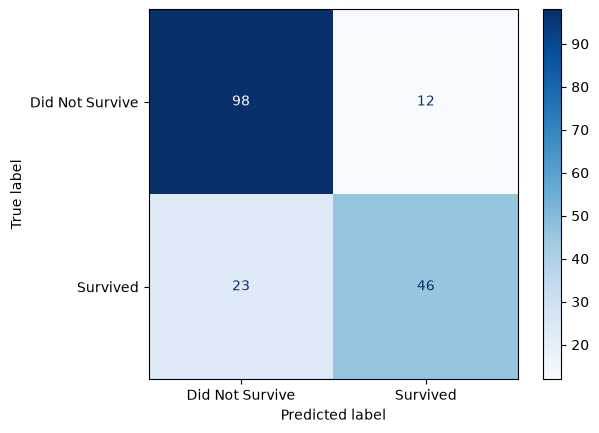

In [10]:
# TODO:

y_pred = model_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(cmap='Blues')
plt.show()

### 9. Classification report

> Print a classification report (precision, recall, f1-score) for the test set.

In [11]:
# TODO:
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



# Interpretation & Predictions

### 10. Pull out your feature names and coefficients

> Your `ColumnTransformer` renames and reorders your columns when it transforms `X`, the numeric columns keep their original names, but the one-hot encoded categorical columns get new names like `Sex_male`. Before you can interpret any coefficient, you need to know which coefficient belongs to which feature.
>
> 1. Get the one-hot encoded feature names out of your fitted `ColumnTransformer` using:
>
>    `.named_steps['preprocessing'].named_transformers_['onehotencoder'].get_feature_names_out(cat_cols)`.
> 
> 2. Combine these with your numeric column names, **in the same order your `ColumnTransformer` outputs them** (e.g. numeric columns first, then categorical).
> 
> 3. Pair these feature names with your fitted model's `.coef_[0]` values in a `pandas.Series` (feature names as the index), so you can look up any coefficient by name.

In [12]:
# TODO:
ohe = model_pipeline.named_steps['preprocessing'].named_transformers_['cat']
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))

feature_names = num_cols + cat_feature_names

coefs = model_pipeline.named_steps['classifier'].coef_[0]
coef_series = pd.Series(coefs, index=feature_names)

print("Feature Coefficients:")
print(coef_series)

Feature Coefficients:
Age          -0.466638
Fare          0.175186
SibSp        -0.260281
Parch        -0.069135
Sex_male     -2.530449
Embarked_Q    0.222367
Embarked_S   -0.436645
Pclass_2     -0.731616
Pclass_3     -1.917942
dtype: float64


### 11. Interpret one coefficient

> Pick one feature and interpret its coefficient. Convert it from log-odds into an odds ratio (`np.exp(coef)`), and explain in a sentence what it does to the odds of survival.

In [13]:
# TODO:
coef_val = coef_series['Sex_male']
odds_ratio = np.exp(coef_val)

print(f"Log-odds coefficient for Sex_male: {coef_val:.4f}")
print(f"Odds Ratio for Sex_male: {odds_ratio:.4f}")

Log-odds coefficient for Sex_male: -2.5304
Odds Ratio for Sex_male: 0.0796


### 12. Generate predictions and predicted probabilities

> Use your model to generate `.predict()` and `.predict_proba()` on the test set. Pick one test observation and explain, in a sentence, what its predicted probability means.

In [14]:
# TODO:
y_probs = model_pipeline.predict_proba(X_test)[:, 1]

sample_idx = 0
sample_prob = y_probs[sample_idx]
sample_pred = y_pred[sample_idx]

print(f"For passenger at index {sample_idx}:")
print(f"Predicted Probability of Survival: {sample_prob:.4f}")
print(f"Predicted Class: {sample_pred}")

For passenger at index 0:
Predicted Probability of Survival: 0.0718
Predicted Class: 0


### 12. Try a different threshold

> `.predict()` uses a default threshold of 0.5 on `.predict_proba()` to decide the class. Try lowering it and recompute the confusion matrix and classification report at this new threshold. What trade-off do you see between precision and recall?

In [15]:
# TODO:
custom_threshold = 0.3
y_pred_custom = (y_probs >= custom_threshold).astype(int)

print(f"--- Classification Report (Threshold = {custom_threshold}) ---")
print(classification_report(y_test, y_pred_custom, target_names=['Did Not Survive', 'Survived']))

--- Classification Report (Threshold = 0.3) ---
                 precision    recall  f1-score   support

Did Not Survive       0.86      0.75      0.80       110
       Survived       0.67      0.80      0.73        69

       accuracy                           0.77       179
      macro avg       0.76      0.78      0.77       179
   weighted avg       0.78      0.77      0.77       179



### 13. Write a function to print classification metrics with explanations

> Write a function `print_classification_metrics(y_true, y_pred)` that calculates **accuracy**, **recall/sensitivity**, **precision**, **specificity**, and **F1 score**, and prints each metric alongside a clear explanation. Then call your function on your model's test set predictions.
>
> Use the confusion matrix layout below as your reference for which cells (`TP`, `TN`, `FP`, `FN`) each metric is built from.

**Accuracy** — Overall, how often is the classifier correct?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center; background-color: red">TN</td>
    <td style="text-align: center">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Accuracy} = \frac{TP + TN}{Total}$$

**Recall / Sensitivity / True Positive Rate (TPR)** — Among all passengers who actually survived, what proportion did we correctly detect?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Recall} = \frac{TP}{TP + FN}$$

**Precision** — Among all passengers predicted to survive, what proportion actually did?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Precision} = \frac{TP}{TP + FP}$$

**Specificity / True Negative Rate (TNR)** — Among all passengers who did not actually survive, what proportion did we correctly detect?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center; background-color: red">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center">TP</td>
</tr>
</table>

$$\textbf{Specificity} = \frac{TN}{TN + FP}$$

**$F_1$ score** — The balance between precision and recall.

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$


In [16]:
# TODO:
def print_classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    
    print("=== Classification Performance Metrics ===")
    print(f"Accuracy:    {acc:.4f} | Overall proportion of correct predictions ( (TP + TN) / Total ).")
    print(f"Recall:      {rec:.4f} | Proportion of actual survivors correctly identified ( TP / (TP + FN) ).")
    print(f"Precision:   {prec:.4f} | Proportion of predicted survivors who actually survived ( TP / (TP + FP) ).")
    print(f"Specificity: {spec:.4f} | Proportion of non-survivors correctly identified ( TN / (TN + FP) ).")
    print(f"F1 Score:    {f1:.4f} | Harmonic mean balancing Precision and Recall ( 2 * (P * R) / (P + R) ).")

print_classification_metrics(y_test, y_pred)

=== Classification Performance Metrics ===
Accuracy:    0.8045 | Overall proportion of correct predictions ( (TP + TN) / Total ).
Recall:      0.6667 | Proportion of actual survivors correctly identified ( TP / (TP + FN) ).
Precision:   0.7931 | Proportion of predicted survivors who actually survived ( TP / (TP + FP) ).
Specificity: 0.8909 | Proportion of non-survivors correctly identified ( TN / (TN + FP) ).
F1 Score:    0.7244 | Harmonic mean balancing Precision and Recall ( 2 * (P * R) / (P + R) ).
